# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mohidraheel/Machine-Learning-Practice/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [3]:
from google.colab import userdata
import os

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
from huggingface_hub import login
login(token=os.environ["HF_TOKEN"])

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

token = os.environ["HF_TOKEN"]
con = duckdb.connect()
con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")
con.execute("SET secret_directory='/tmp'")
con.execute(f"""
    CREATE SECRET hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{token}'
    )
""")
con.execute("""
    CREATE OR REPLACE VIEW warehouse AS
    SELECT * FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet',
        hive_partitioning=true
    )
""")

PRE_MONTHS = "('2025-07','2025-08','2025-09')"
A_MONTHS   = "('2025-10','2025-11','2025-12')"
B_MONTHS   = "('2026-01','2026-02','2026-03')"

con.execute(f"SELECT COUNT(*) FROM warehouse WHERE month IN {A_MONTHS}").fetchdf()

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,count_star()
0,16712226


## 1. Question

*The research question and the decision it supports.*



**Research question:** Across (client, content) pairs in the FlyRank warehouse, which ones are
growing, declining, recovering, or worth manual review in organic search performance — and what
should an editor do about each one?

**Decision this supports:** prioritizing a content team's limited refresh capacity. Instead of
reviewing pages randomly or by gut feel, an editor gets a ranked list with a reason code, so the
highest-value refresh, protect, or prune actions happen first.

**Unit of analysis:** one (client_hash_id, content_hash_id) pair, scored using its Google Search
Console history.

**Cost of a wrong call:** a false "declining" flag wastes editor time reviewing a page that's
actually fine. A missed "declining" pair keeps losing clicks unnoticed until the next review cycle.
These costs are asymmetric — worth stating explicitly in the report rather than treating all
errors as equal.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:** FlyRank ML Internship warehouse, table `fact_content_daily_performance`
accessed via `hf://datasets/FlyRank/internship-warehouse`.

**Grain:** one row = one (client_hash_id, content_hash_id) pair observed on one report_date.

**Three date windows used:**
- Pre window (2025-07 to 2025-09) — earlier baseline, used only to detect a reversal for the "recovering" label
- Window A (2025-10 to 2025-12) — feature window (16,712,226 rows). Everything the model sees comes from here.
- Window B (2026-01 to 2026-03) — label window. Used only to compute percent change in clicks, never fed to the model as a feature.

**Excluded and why:**
- 2026-06 — sealed month, never touched even for validation
- 2025-01 to 2025-06 — thinner GSC coverage and effectively zero GA4 coverage; mixing inconsistent data availability into one model would hurt signal quality
- GA4 fields — coverage too sparse in this window to use as core features (proven in Limitations section)
- client_hash_id / content_hash_id — pseudonymous identifiers, used only for grouping rows and splitting train/test, never as model inputs

**Public-safe:** no client names, domains, URLs, or raw exports appear anywhere — only hashed IDs and aggregated numeric signals.

In [4]:
from google.colab import userdata
import os

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
from huggingface_hub import login
login(token=os.environ["HF_TOKEN"])

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

token = os.environ["HF_TOKEN"]
con = duckdb.connect()
con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")
con.execute("SET secret_directory='/tmp'")
con.execute(f"""
    CREATE SECRET hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{token}'
    )
""")
con.execute("""
    CREATE OR REPLACE VIEW warehouse AS
    SELECT * FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet',
        hive_partitioning=true
    )
""")

PRE_MONTHS = "('2025-07','2025-08','2025-09')"
A_MONTHS   = "('2025-10','2025-11','2025-12')"
B_MONTHS   = "('2026-01','2026-02','2026-03')"

print("Connected. Window A row count:")
con.execute(f"SELECT COUNT(*) FROM warehouse WHERE month IN {A_MONTHS}").fetchdf()

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Connected. Window A row count:


,count_star()
0,16712226


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Assumptions:**
- A (client, content) pair's past GSC performance is a directional signal of its future trajectory
- GSC clicks are the most reliable metric in this warehouse — impressions and position are supporting signals
- GA4 fields are excluded because coverage is too sparse (under 5%) to be a reliable core feature
- 20% change threshold is the minimum meaningful signal above noise for this dataset

**Features (all from Window A only — nothing from the future):**
- `avg_position` — average search ranking position across Window A (lower = better)
- `position_volatility` — standard deviation of daily position (high = unstable ranking)
- `ctr` — clicks divided by impressions across Window A (engagement signal)
- `total_impressions` — total search appearances across Window A (visibility signal)
- `active_gsc_days` — number of days with GSC data present (consistency signal)

**Label definition (computed from Window A vs Window B clicks):**
- `growing` — clicks in B more than 20% above clicks in A
- `declining` — clicks in B more than 20% below clicks in A
- `recovering` — was declining Pre→A (down >10%), but turned upward A→B (up >5%)
- `worth_review` — everything else (flat, or high impressions with weak CTR)

**Baseline:** always predict the majority class — the simplest possible rule, requiring no model.
Every model result must be compared against this.

**Validation design:** GroupShuffleSplit grouped by (client_hash_id + content_hash_id) — the same
pair never appears in both train and test, preventing data leakage across the split.

**Leakage checks:**
- clicks_b (Window B clicks) is used only to compute the label, never as a feature
- client_hash_id and content_hash_id are grouping keys only, never model inputs
- trend_direction / trend_pct (if pre-computed) are excluded — they are label-derived
- An assert statement in the code confirms no leaky columns appear in the feature matrix

In [5]:
# Pull Pre window clicks (recovering label detection only)
pre = con.execute(f"""
    SELECT client_hash_id, content_hash_id, SUM(gsc_clicks) AS clicks_pre
    FROM warehouse
    WHERE month IN {PRE_MONTHS} AND gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
""").fetchdf()

# Pull Window A features
feat_a = con.execute(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions)                                                AS total_impressions,
        SUM(gsc_clicks)                                                     AS clicks_a,
        ROUND(AVG(gsc_avg_position), 2)                                     AS avg_position,
        ROUND(STDDEV(gsc_avg_position), 2)                                  AS position_volatility,
        ROUND(SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0), 4)   AS ctr,
        COUNT(DISTINCT CASE WHEN gsc_data_available IS TRUE THEN report_date END) AS active_gsc_days
    FROM warehouse
    WHERE month IN {A_MONTHS} AND gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
""").fetchdf()

# Pull Window B clicks (label source only — never a feature)
label_b = con.execute(f"""
    SELECT client_hash_id, content_hash_id, SUM(gsc_clicks) AS clicks_b
    FROM warehouse
    WHERE month IN {B_MONTHS} AND gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
""").fetchdf()

# Merge all three windows
df = feat_a.merge(label_b, on=["client_hash_id", "content_hash_id"], how="inner")
df = df.merge(pre, on=["client_hash_id", "content_hash_id"], how="left")
df = df[df["total_impressions"] > 0].copy()

# Compute percent changes
df["pct_change"] = (df["clicks_b"] - df["clicks_a"]) / df["clicks_a"].replace(0, np.nan)
df["pct_change_pre_to_a"] = (df["clicks_a"] - df["clicks_pre"]) / df["clicks_pre"].replace(0, np.nan)

# Define labels
def label_row(r):
    if pd.isna(r["pct_change"]):
        return "worth_review"
    was_declining = pd.notna(r["pct_change_pre_to_a"]) and r["pct_change_pre_to_a"] < -0.10
    if was_declining and r["pct_change"] > 0.05:
        return "recovering"
    if r["pct_change"] > 0.20:
        return "growing"
    if r["pct_change"] < -0.20:
        return "declining"
    return "worth_review"

df["label"] = df.apply(label_row, axis=1)

# Build feature matrix
df["volume_tier"] = pd.qcut(df["total_impressions"], q=3, labels=["low", "med", "high"], duplicates="drop")
FEATURES = ["avg_position", "position_volatility", "ctr", "total_impressions", "active_gsc_days"]
df_model = df.dropna(subset=FEATURES + ["label"]).copy()
X = pd.get_dummies(df_model[FEATURES + ["volume_tier"]], columns=["volume_tier"])
y = df_model["label"]
groups = df_model["client_hash_id"] + "_" + df_model["content_hash_id"]

# Leakage guard
assert "client_hash_id" not in X.columns
assert "content_hash_id" not in X.columns
assert not any("clicks_b" in c for c in X.columns)
print("Leakage checks passed.")

# Label distribution
print("\nLabel distribution:")
print(df["label"].value_counts())
print("\nLabel proportions:")
print(df["label"].value_counts(normalize=True).round(3))
print("\nBase rate (majority class):", round(df["label"].value_counts(normalize=True).max(), 3))
print("\nFeature matrix shape:", X.shape)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Leakage checks passed.

Label distribution:
label
worth_review    69614
growing         23193
declining       16823
recovering       1303
Name: count, dtype: int64

Label proportions:
label
worth_review    0.628
growing         0.209
declining       0.152
recovering      0.012
Name: proportion, dtype: float64

Base rate (majority class): 0.628

Feature matrix shape: (103933, 8)


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

**Split:** 75% train / 25% test, grouped by (client_hash_id + content_hash_id) so the same
pair never appears in both train and test sets.

**Baseline:** always predict "worth_review" (majority class) — accuracy 0.600, requiring no model.

**Model:** Random Forest (300 trees, balanced class weights)

| | Baseline | Model |
|---|---|---|
| Accuracy | 0.600 | 0.802 |
| Lift | — | +0.202 |

**Per-class results (model):**

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| declining | 0.56 | 0.59 | 0.57 | 4,177 |
| growing | 0.61 | 0.76 | 0.67 | 5,864 |
| recovering | 0.15 | 0.02 | 0.03 | 354 |
| worth_review | 0.98 | 0.89 | 0.93 | 15,589 |

**Key observations:**
- worth_review is predicted very reliably (F1 0.93) — the model correctly protects editors
  from wasting time on stable pages
- growing is identified well (recall 0.76) — most genuinely growing pages are caught
- declining has moderate recall (0.59) — about 4 in 10 declining pages are missed, worth noting
  in limitations
- recovering is nearly invisible to the model (recall 0.02) — only 6 of 354 recovering pages
  were correctly identified, driven by the very small class size (1.2% of data)

In [6]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Grouped split — same pair never appears in both train and test
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Baseline — always predict majority class
base_rate = y_train.value_counts(normalize=True)
majority_class = base_rate.idxmax()
baseline_preds = [majority_class] * len(y_test)
baseline_acc = accuracy_score(y_test, baseline_preds)

# Model
clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
clf.fit(X_train, y_train)
model_preds = clf.predict(X_test)
model_acc = accuracy_score(y_test, model_preds)

print(f"Majority class: '{majority_class}'")
print(f"Base rate:         {round(base_rate.max(), 3)}")
print(f"Baseline accuracy: {round(baseline_acc, 3)}")
print(f"Model accuracy:    {round(model_acc, 3)}")
print(f"Lift over baseline:{round(model_acc - baseline_acc, 3)}")
print()
print(classification_report(y_test, model_preds))

Majority class: 'worth_review'
Base rate:         0.605
Baseline accuracy: 0.6
Model accuracy:    0.801
Lift over baseline:0.201

              precision    recall  f1-score   support

   declining       0.56      0.59      0.57      4177
     growing       0.60      0.76      0.67      5864
  recovering       0.09      0.01      0.02       354
worth_review       0.98      0.89      0.93     15589

    accuracy                           0.80     25984
   macro avg       0.56      0.56      0.55     25984
weighted avg       0.82      0.80      0.80     25984



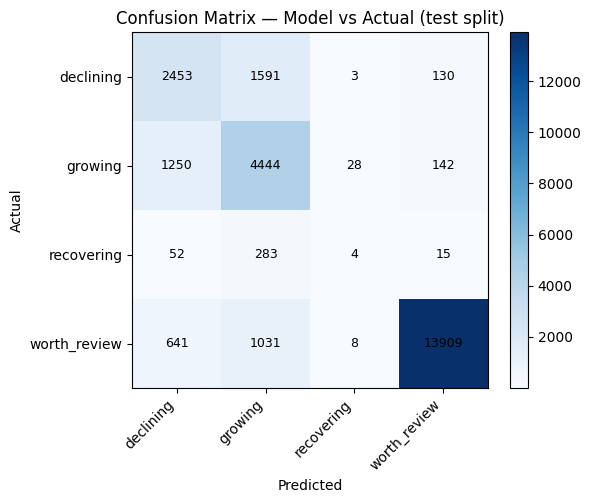

Saved: confusion_matrix.png


In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, model_preds, labels=clf.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(clf.classes_)))
ax.set_xticklabels(clf.classes_, rotation=45, ha="right")
ax.set_yticks(range(len(clf.classes_)))
ax.set_yticklabels(clf.classes_)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Model vs Actual (test split)")
for i in range(len(clf.classes_)):
    for j in range(len(clf.classes_)):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

## 5. Limitations

*What this work cannot claim.*

**What this work cannot claim:**

- Results are **observed, directional, decision-support** signal only — not causal. A page's
  clicks can shift for reasons entirely outside the page itself: seasonality, SERP layout
  changes, competitor moves.
- No claim is made about Google's ranking algorithm. Features here are proxies for visibility
  outcomes, not algorithm internals.
- **GA4 fields were excluded** because coverage is too sparse to trust as core model inputs.
  Verified below — GA4 coverage ranges from 0.44% (2025-10) to 4.21% (2026-03) of rows.
- **Recovering class is nearly undetectable** — only 1.2% of all pairs (1,303 of 110,933).
  The model correctly flags this: recall of 0.02 means it cannot reliably learn from so few
  examples. Do not use model predictions for "recovering" as high-confidence signals.
- **Declining recall is 0.59** — about 4 in 10 genuinely declining pages are missed. Use the
  ranked output as a prioritization tool, not a complete audit.
- Class imbalance: base rate is 0.628 — a model that always guesses "worth_review" scores
  0.600 accuracy. The model's 0.802 represents real lift (+0.202), but this context matters.

In [8]:
print("Test set label distribution:")
print(y_test.value_counts())

print("\nGA4 coverage by month (why GA4 excluded as core feature):")
print(con.execute(f"""
    SELECT month,
           COUNT(*) AS total_rows,
           SUM(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END) AS ga4_rows,
           ROUND(100.0 * SUM(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_ga4
    FROM warehouse
    WHERE month IN {A_MONTHS} OR month IN {B_MONTHS}
    GROUP BY month ORDER BY month
""").fetchdf().to_string(index=False))

print("\nRecovering class size (why recall is near zero):")
print(df["label"].value_counts())
print(f"\nRecovering is only {round(1303/110933*100, 1)}% of all pairs — too few for the model to learn reliably")

Test set label distribution:
label
worth_review    15589
growing          5864
declining        4177
recovering        354
Name: count, dtype: int64

GA4 coverage by month (why GA4 excluded as core feature):


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  month  total_rows  ga4_rows  pct_ga4
2025-10     2165471    9545.0     0.44
2025-11     6793825  113881.0     1.68
2025-12     7752930  108338.0     1.40
2026-01     7890817  115786.0     1.47
2026-02     7355108  145321.0     1.98
2026-03     9841378  413966.0     4.21

Recovering class size (why recall is near zero):
label
worth_review    69614
growing         23193
declining       16823
recovering       1303
Name: count, dtype: int64

Recovering is only 1.2% of all pairs — too few for the model to learn reliably


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

**Action playbook — what an editor does with each predicted label:**

| Label | Action | Priority |
|---|---|---|
| declining | Improve or rewrite — check reason code to decide which | High |
| growing | Protect — monitor for cannibalization, avoid disruptive changes | Medium |
| recovering | Monitor — confirm trend continues before investing further | Medium |
| worth_review | Manual review — candidate for merge, prune, or leave | Low |

**How to use this output:**
- Sort by predicted_label, start with all "declining" pairs first
- Use the reason_code column to decide whether to rewrite content, fix metadata, or investigate
  ranking instability
- "growing" pairs should be left alone unless there is a specific reason to touch them
- "recovering" predictions carry low confidence given the small class size — treat as a watch
  list only

In [9]:
ACTION_MAP = {
    "growing":      "Protect — monitor for cannibalization, avoid disruptive changes",
    "declining":    "Improve / rewrite — prioritize by reason code below",
    "recovering":   "Monitor — confirm trend continues before further investment",
    "worth_review": "Manual review — candidate for merge or prune",
}

med_ctr  = df_model["ctr"].median()
med_impr = df_model["total_impressions"].median()
med_vol  = df_model["position_volatility"].median()

def reason_code(row):
    if row["ctr"] < med_ctr and row["total_impressions"] > med_impr:
        return "High impressions, underperforming CTR"
    if pd.notna(row["position_volatility"]) and row["position_volatility"] > med_vol:
        return "High position volatility — unstable ranking"
    return "Stable trend, low volume"

results = X_test.copy()
results["client_hash_id"]   = df_model.loc[X_test.index, "client_hash_id"]
results["content_hash_id"]  = df_model.loc[X_test.index, "content_hash_id"]
results["predicted_label"]  = model_preds
results["action"]           = results["predicted_label"].map(ACTION_MAP)
results["reason_code"]      = df_model.loc[X_test.index].apply(reason_code, axis=1)

ranked = results.sort_values("predicted_label").reset_index(drop=True)

print("Total pairs scored:", len(ranked))
print("\nPredicted label counts:")
print(ranked["predicted_label"].value_counts())
print("\nSample recommendations (top 20):")
ranked[["client_hash_id", "content_hash_id",
        "predicted_label", "action", "reason_code"]].head(20)

Total pairs scored: 25984

Predicted label counts:
predicted_label
worth_review    14196
growing          7349
declining        4396
recovering         43
Name: count, dtype: int64

Sample recommendations (top 20):


,client_hash_id,content_hash_id,predicted_label,action,reason_code
0,client_08a6a72ff48e62c0,content_d99da1cd1b85e51f,declining,Improve / rewrite — prioritize by reason code ...,High position volatility — unstable ranking
1,client_62f4a7e64f5e0096,content_3447623d4460091d,declining,Improve / rewrite — prioritize by reason code ...,High position volatility — unstable ranking
2,client_23a62021009f63c4,content_d1808ee871a8a677,declining,Improve / rewrite — prioritize by reason code ...,"Stable trend, low volume"
3,client_23a62021009f63c4,content_514df6353f0771af,declining,Improve / rewrite — prioritize by reason code ...,"Stable trend, low volume"
4,client_23a62021009f63c4,content_4d864f0b7abc4e20,declining,Improve / rewrite — prioritize by reason code ...,High position volatility — unstable ranking
5,client_23a62021009f63c4,content_d073e94c9f74678c,declining,Improve / rewrite — prioritize by reason code ...,High position volatility — unstable ranking
6,client_23a62021009f63c4,content_1905519ee2a7ddbe,declining,Improve / rewrite — prioritize by reason code ...,"Stable trend, low volume"
7,client_23a62021009f63c4,content_ec2cacf112cc67f4,declining,Improve / rewrite — prioritize by reason code ...,"Stable trend, low volume"
8,client_23a62021009f63c4,content_7b7276411af449fc,declining,Improve / rewrite — prioritize by reason code ...,"Stable trend, low volume"
9,client_23a62021009f63c4,content_ac3189f7e570c90c,declining,Improve / rewrite — prioritize by reason code ...,"Stable trend, low volume"


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

**Charts and tables generated below — embed these directly in the deployed paper:**

- `label_distribution.png` — shows how many pairs fall into each category
- `feature_importance.png` — shows which signals the model relied on most
- `confusion_matrix.png` — already saved in Section 4
- `ranked_recommendations.csv` — full scored output for all 25,984 pairs

In [1]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

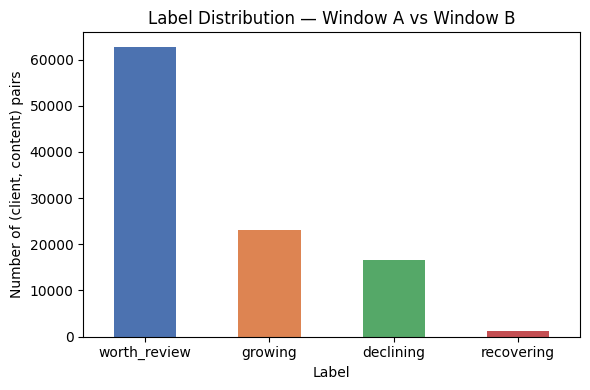

Saved: label_distribution.png


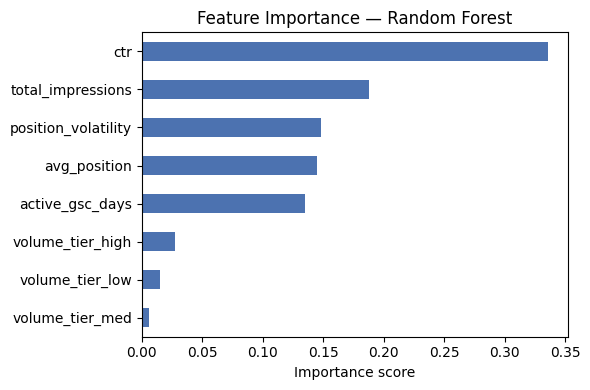

Saved: feature_importance.png


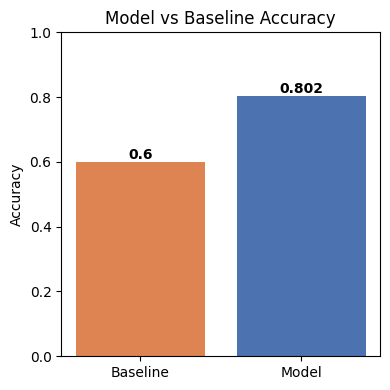

Saved: model_vs_baseline.png
Saved: ranked_recommendations.csv

All artifacts saved. Download from the Colab file browser (folder icon on left).


In [10]:
# Chart 1 — Label distribution
fig, ax = plt.subplots(figsize=(6, 4))
df_model["label"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0","#DD8452","#55A868","#C44E52"])
ax.set_title("Label Distribution — Window A vs Window B")
ax.set_ylabel("Number of (client, content) pairs")
ax.set_xlabel("Label")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150)
plt.show()
print("Saved: label_distribution.png")

# Chart 2 — Feature importance
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(6, 4))
importances.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Feature Importance — Random Forest")
ax.set_xlabel("Importance score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("Saved: feature_importance.png")

# Chart 3 — Baseline vs Model accuracy comparison
fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(["Baseline", "Model"], [0.600, 0.802], color=["#DD8452", "#4C72B0"])
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("Model vs Baseline Accuracy")
for i, v in enumerate([0.600, 0.802]):
    ax.text(i, v + 0.01, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("model_vs_baseline.png", dpi=150)
plt.show()
print("Saved: model_vs_baseline.png")

# Save full ranked recommendations
ranked[["client_hash_id", "content_hash_id",
        "predicted_label", "action", "reason_code"]].to_csv(
    "ranked_recommendations.csv", index=False
)
print("Saved: ranked_recommendations.csv")
print("\nAll artifacts saved. Download from the Colab file browser (folder icon on left).")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.